# Estimación de la dispersión en el alcance de un proyectil

Consideramos un cañón que dispara proyectiles con velocidad inicial fija $v_0$, pero cuyo ángulo de lanzamiento $\theta$ tiene una pequeña variabilidad aleatoria. En el régimen de pequeñas variaciones, la variación en el alcance horizontal
$$
R = \frac{v_0^2 \sin 2\theta}{g}
$$
es también aproximadamente normal con media $\mu_R$ y desviación estándar $\sigma_R$.

Supongamos que en cada "experimento" realizamos $n = 2$ disparos y queremos estimar $\sigma_R$ a partir de esos datos. Comparamos dos estimadores:
$$
t_1 = \sqrt{s^2}, \qquad t_2 = \sqrt{\frac{\pi}{2} s^2}
$$
donde $s^2$ es la varianza muestral con corrección de Bessel ($\mathrm{ddof}=1$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp

## Parámetros del problema

Usamos valores típicos de un experimento de tiro:
- Alcance medio: $\mu_R = 200\,\mathrm{m}$
- Dispersión real: $\sigma_R = 15\,\mathrm{m}$
- Disparos por experimento: $n = 2$
- Número de experimentos repetidos: $N = 1000$

In [2]:
n_samples = 1000        # número de experimentos
n_disparos = 2      # disparos por experimento
mu_R = 200.0        # alcance medio (m)
sigma_R = 15.0      # dispersión real (m)

# Simulamos las mediciones de alcance
# Cada fila es un experimento con n_disparos mediciones
R = np.random.normal(loc=mu_R, scale=sigma_R, size=(n_samples, n_disparos))

# Varianza muestral con corrección de Bessel (ddof=1)
s2 = np.var(R, ddof=1, axis=1)

# Los dos estimadores de sigma_R
t1 = np.sqrt(s2)
t2 = np.sqrt(np.pi * s2 / 2)

## Histogramas de $t_1$ y $t_2$

Graficamos las distribuciones empíricas de ambos estimadores junto a la línea vertical del valor real $\sigma_R = 15\,\mathrm{m}$.

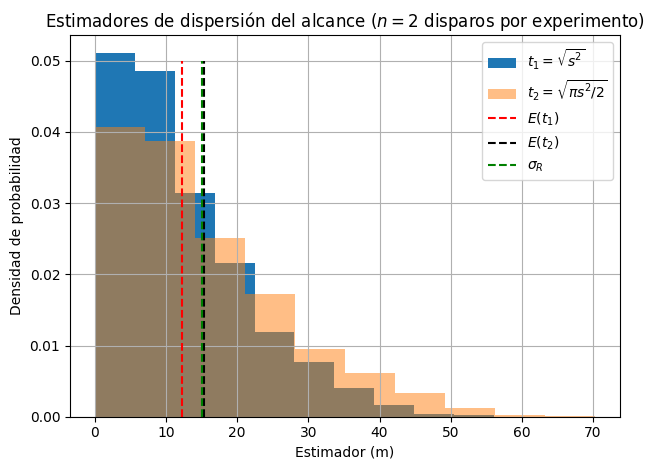

In [3]:
plt.hist(t1, label='$t_1 = \\sqrt{s^2}$', density=True)
plt.hist(t2, label='$t_2 = \\sqrt{\\pi s^2/2}$', density=True, alpha=0.5)

plt.vlines(np.mean(t1), 0, 0.05, label='$E(t_1)$', linestyle='dashed', color='red')
plt.vlines(np.mean(t2), 0, 0.05, label='$E(t_2)$', linestyle='dashed', color='black')
plt.vlines(sigma_R,     0, 0.05, label='$\\sigma_R$', linestyle='dashed', color='green')

plt.title('Estimadores de dispersión del alcance ($n=2$ disparos por experimento)')
plt.xlabel('Estimador (m)')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Sesgo de cada estimador

El sesgo se define como
$$
B(t_i) = E(t_i) - \sigma_R
$$
Un estimador es **insesgado** si $B = 0$.

In [4]:
bias_t1 = np.mean(t1) - sigma_R
bias_t2 = np.mean(t2) - sigma_R

print(f'E(t1) = {np.mean(t1):.3f} m    B(t1) = {bias_t1:.3f} m')
print(f'E(t2) = {np.mean(t2):.3f} m    B(t2) = {bias_t2:.3f} m')
print(f'Valor real: sigma_R = {sigma_R:.3f} m')

E(t1) = 12.229 m    B(t1) = -2.771 m
E(t2) = 15.327 m    B(t2) = 0.327 m
Valor real: sigma_R = 15.000 m


## Explicación del sesgo

Se puede demostrar que el estimador $s^2$ **es insesgado** para la varianza: $E(s^2) = \sigma_R^2$. Sin embargo, eso **no implica** que $t_1 = \sqrt{s^2}$ sea insesgado para $\sigma_R$, porque la raíz cuadrada es una función no lineal. En general:
$$
E(\sqrt{s^2}) \neq \sqrt{E(s^2)}
$$

Para una distribución normal, puede calcularse analíticamente que
$$
E(\sqrt{s^2}) = c_4(n)\, \sigma_R, \quad \text{con} \quad c_4(2) = \sqrt{\frac{2}{\pi}}
$$

de modo que $t_1$ **subestima** $\sigma_R$ por un factor $\sqrt{2/\pi} \approx 0.798$.

El estimador corregido $t_2 = \sqrt{\pi/2}\, t_1$ justamente cancela ese factor, resultando insesgado:

In [5]:
c4 = np.sqrt(2 / np.pi)
print(f'c4(2) = sqrt(2/pi) = {c4:.4f}')
print(f'Valor esperado teórico de t1: c4 * sigma_R = {c4 * sigma_R:.3f} m')
print(f'Valor simulado de E(t1):{np.mean(t1):.3f} m')
print()
print(f'Factor de corrección de t2: sqrt(pi/2) = {np.sqrt(np.pi/2):.4f} = 1/c4')
print(f'Entonces E(t2) = sqrt(pi/2) * c4 * sigma_R = sigma_R = {sigma_R:.3f} m  ✓')

c4(2) = sqrt(2/pi) = 0.7979
Valor esperado teórico de t1: c4 * sigma_R = 11.968 m
Valor simulado de E(t1):12.229 m

Factor de corrección de t2: sqrt(pi/2) = 1.2533 = 1/c4
Entonces E(t2) = sqrt(pi/2) * c4 * sigma_R = sigma_R = 15.000 m  ✓


## Conclusiones

Simulamos 1000 experimentos de 2 disparos cada uno y comparamos dos estimadores de la dispersión en el alcance:

- $t_1 = \sqrt{s^2}$ es **sesgado**: subestima $\sigma_R$ por un factor $c_4(2) = \sqrt{2/\pi} \approx 0.80$.
- $t_2 = \sqrt{\pi s^2/2}$ corrige exactamente ese sesgo y resulta **insesgado**.

La causa de fondo es que la insesgadez de $s^2$ no se transfiere a $\sqrt{s^2}$ por la no linealidad de la raíz: $E(\sqrt{X}) \neq \sqrt{E(X)}$ en general. En la práctica, cuando $n$ es pequeño (como $n=2$ aquí), este sesgo es considerable y vale la pena corregirlo.